# **Model 2**

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import kagglehub


path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

data_dir = os.path.join(path, 'EuroSAT')

IMG_SIZE = (64, 64)
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=26,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=26,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Classes: {class_names}")



Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
### Step 2

num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(64, 64, 3)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,501,002 (24.80 MB)

 Trainable params: 6,501,002 (24.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)



Epoch 1/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 357s 1s/step - accuracy: 0.4529 - loss: 1.4504 - val_accuracy: 0.5643 - val_loss: 1.2083
Epoch 2/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 322s 953ms/step - accuracy: 0.6482 - loss: 0.9871 - val_accuracy: 0.7226 - val_loss: 0.7611
Epoch 3/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.7160 - loss: 0.8024 - val_accuracy: 0.7143 - val_loss: 0.7993
Epoch 4/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.7448 - loss: 0.7157 - val_accuracy: 0.7972 - val_loss: 0.5735
Epoch 5/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 341s 937ms/step - accuracy: 0.7771 - loss: 0.6274 - val_accuracy: 0.7478 - val_loss: 0.6770
Epoch 6/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 349s 1s/step - accuracy: 0.7847 - loss: 0.6026 - val_accuracy: 0.8120 - val_loss: 0.5408
Epoch 7/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 331s 979ms/step - accuracy: 0.8067 - loss: 0.5443 - val_accuracy: 0.8013 - val_loss: 0.5381
Epoch 8/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.8213 - loss: 0.5011 -

Evaluating model on validation set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0

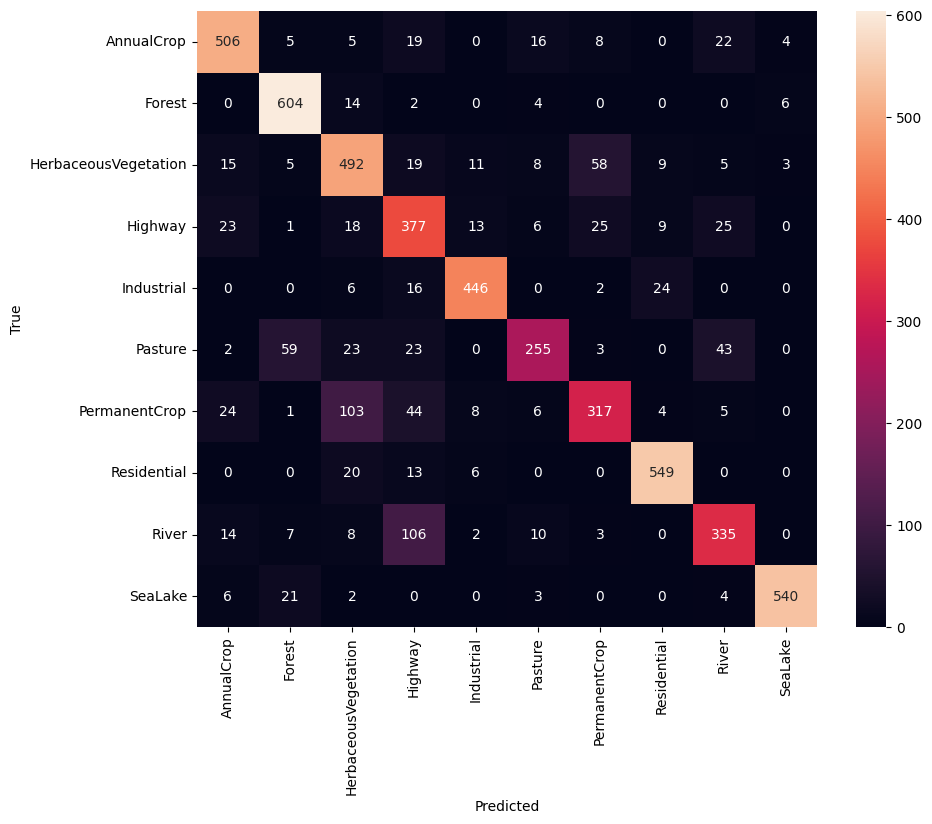

                      precision    recall  f1-score   support

          AnnualCrop       0.86      0.86      0.86       585
              Forest       0.86      0.96      0.91       630
HerbaceousVegetation       0.71      0.79      0.75       625
             Highway       0.61      0.76      0.68       497
          Industrial       0.92      0.90      0.91       494
             Pasture       0.83      0.62      0.71       408
       PermanentCrop       0.76      0.62      0.68       512
         Residential       0.92      0.93      0.93       588
               River       0.76      0.69      0.73       485
             SeaLake       0.98      0.94      0.96       576

            accuracy                           0.82      5400
           macro avg       0.82      0.81      0.81      5400
        weighted avg       0.82      0.82      0.82      5400



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure val_ds and model exist before running
try:
    # Get labels and predictions for validation set
    y_true = []
    y_pred = []
    print("Evaluating model on validation set...")
    for x, y in val_ds:
        y_true.extend(y.numpy())
        preds = model.predict(x, verbose=1)
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names))
except NameError as e:
    print(f"Error: {e}. Run the Data Loading (Step 1) and Training (Step 3) cells first.")